Imports and Setup
numpy: For numerical operations, such as array manipulation.
matplotlib.pyplot: For visualizing images and plotting graphs like accuracy and loss.
ImageDataGenerator: Used for loading and augmenting image data (rescaling, rotating, flipping, etc.).
Sequential: The model is built sequentially, layer by layer.
Conv2D, MaxPooling2D, Flatten, Dense: Layers used in the Convolutional Neural Network (CNN). Conv2D is for convolution, MaxPooling2D is for down-sampling, Flatten converts a 2D matrix into a 1D vector, and Dense is a fully connected layer.
cv2: For computer vision tasks, such as real-time face detection in the webcam.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import History
import random
import cv2


Up Image Size, Batch Size, and Data Directories
img_size: The size to which each image will be resized (48x48 pixels).
batch_size: The number of images to be processed in one pass (64 images per batch).
train_dir and test_dir: Paths to the training and testing datasets.

In [27]:
img_size = 48
batch_size = 64
train_dir = 'C:\\Users\\Saif\\Desktop\\Project_DL\\dataset\\images1\\train'
test_dir = 'C:\\Users\\Saif\\Desktop\\Project_DL\\FER13_cleaner\\test'


Set Up ImageDataGenerators

rescale=1./255: Normalizes the pixel values from [0, 255] to [0, 1], which helps the model train more effectively.

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, 
rotation_range=20, 
zoom_range=0.2, 
horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)


Load the Training and Testing Data
This method loads the images from directories. 
Resizes images to 48x48 pixels.
The number of images processed together in one batch.
Images are loaded as grayscale (one channel).
The labels are  (7 categories).

In [ ]:
train_data = train_datagen.flow_from_directory(train_dir, 
target_size=(img_size, img_size), 
batch_size=batch_size, 
color_mode='grayscale', 
class_mode='categorical')

test_data = test_datagen.flow_from_directory(test_dir, 
target_size=(img_size, img_size), 
batch_size=batch_size, 
color_mode='grayscale', 
class_mode='categorical')


Found 28044 images belonging to 7 classes.
Found 7121 images belonging to 7 classes.


Define the CNN Model
Sequential(): Defines the sequential model where layers are stacked one after another.
A convolutional layer with 32 filters, a 3x3 kernel size, and ReLU activation. The input_shape is set to (48, 48, 1) for grayscale images of size 48x48.
A pooling layer with a pool size of 2x2, reducing the spatial dimensions by half.
Flattens the 2D matrix into a 1D vector.
A fully connected layer with 1000 neurons and ReLU activation.
Output layer with 7 neurons (one for each emotion) and softmax activation for multi-class classification.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = tf.keras.Sequential([ 
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    MaxPooling2D(2, 2),  
    
    Conv2D(64, (3, 3), activation='relu'),  
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'), 
    MaxPooling2D(2, 2),  

    Conv2D(256, (3, 3), activation='relu'),  
    MaxPooling2D(2, 2),  

    Flatten(),  
    Dense(1000, activation='relu'), 
    Dense(7, activation='softmax')  
])


c:\Users\Saif\Desktop\Project_DL\myenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the Model
Adam optimizer is used for training.
The loss function for multi-class classification.
track accuracy during training.

In [31]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


Plot Random Training Data Before Training
 A function that:
Selects a random batch of images from the training data.
Displays 5 random images with their corresponding labels (converted from one-hot encoded values to their index).
Displays an image in grayscale.
Sets the title of the plot to the predicted class label.

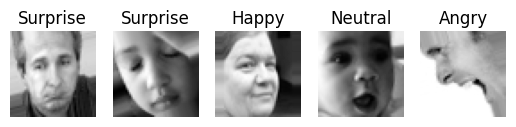

In [78]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

def plot_random_training_data():
    
    batch = next(train_data)
    images, labels = batch[0], batch[1]
    
    
    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        
        
        label_index = np.argmax(labels[i])
        emotion_name = emotion_labels[label_index]
        
        
        plt.title(emotion_name)
        plt.axis('off')
    
    
    plt.show()


plot_random_training_data()


Train the Model
Trains the model using the training data for 50 epochs, validating it after each epoch with the test data.
The model will evaluate the test data after each epoch.

In [ ]:
model_history = model.fit(train_data, epochs=10, validation_data=test_data)


Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 61s 133ms/step - accuracy: 0.2478 - loss: 1.8211 - val_accuracy: 0.2612 - val_loss: 1.7709
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 124ms/step - accuracy: 0.2984 - loss: 1.7193 - val_accuracy: 0.4060 - val_loss: 1.5267
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 57s 130ms/step - accuracy: 0.4057 - loss: 1.5312 - val_accuracy: 0.4599 - val_loss: 1.3794
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 124ms/step - accuracy: 0.4461 - loss: 1.4182 - val_accuracy: 0.5002 - val_loss: 1.3030
Epoch 5/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 58s 133ms/step - accuracy: 0.4866 - loss: 1.3462 - val_accuracy: 0.5173 - val_loss: 1.2571
Epoch 6/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 59s 135ms/step - accuracy: 0.5063 - loss: 1.2847 - val_accuracy: 0.5266 - val_loss: 1.2265
Epoch 7/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 52s 118ms/step - accuracy: 0.5235 - loss: 1.2527 - val_accuracy: 0.5444 - val_loss: 1.1978
Epoch 8/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.5293 - loss: 1

Evaluate the Model on Test Data
Evaluates the trained model on the test data and returns the loss and accuracy.
Displays the accuracy of the model on the test set.

In [34]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Accuracy: {test_accuracy:.2f}")


112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5684 - loss: 1.1353
Test Accuracy: 0.57


Plot Accuracy and Loss Graphs
This function creates two plots:
The first subplot shows the training and validation accuracy over epochs.
The second subplot shows the training and validation loss over epochs.

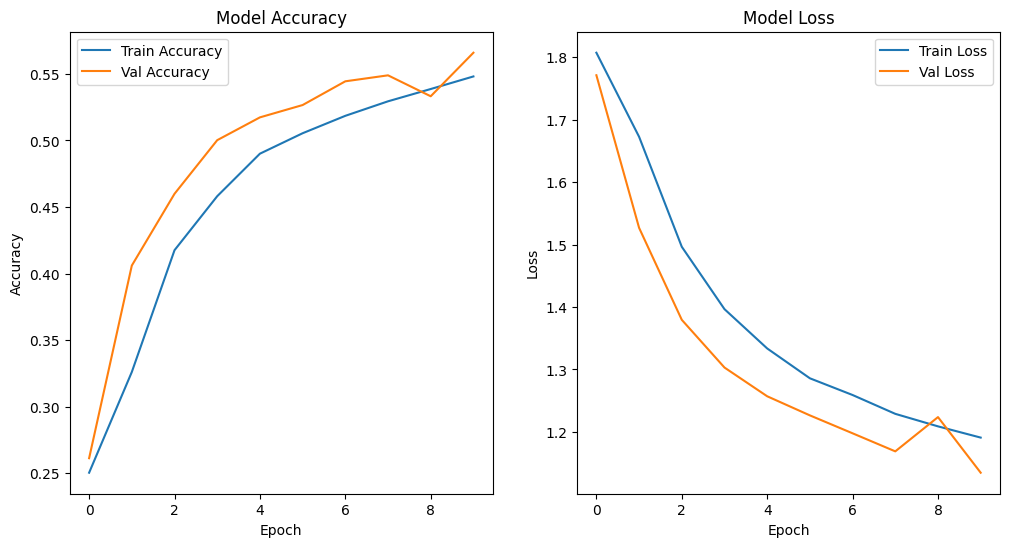

In [ ]:

def plot_accuracy_loss(training_history):
    
    plt.figure(figsize=(12, 6))
    
    
    plt.subplot(1, 2, 1)
    plt.plot(training_history.history['accuracy'], label='Train Accuracy')
    plt.plot(training_history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    
    plt.subplot(1, 2, 2)
    plt.plot(training_history.history['loss'], label='Train Loss')
    plt.plot(training_history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    
    plt.show()


plot_accuracy_loss(model_history)


Show Predictions on Test Data

Selects a batch from the test data and makes predictions using the trained model.
Displays the predicted and true labels for each image.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step 


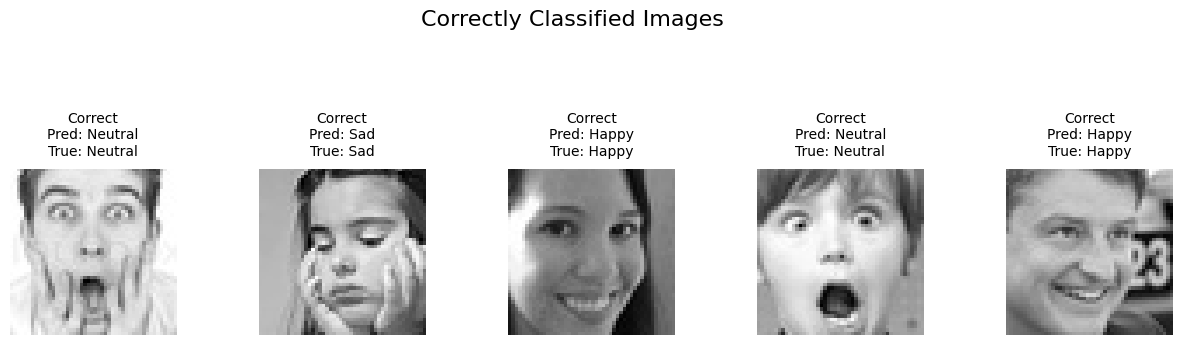

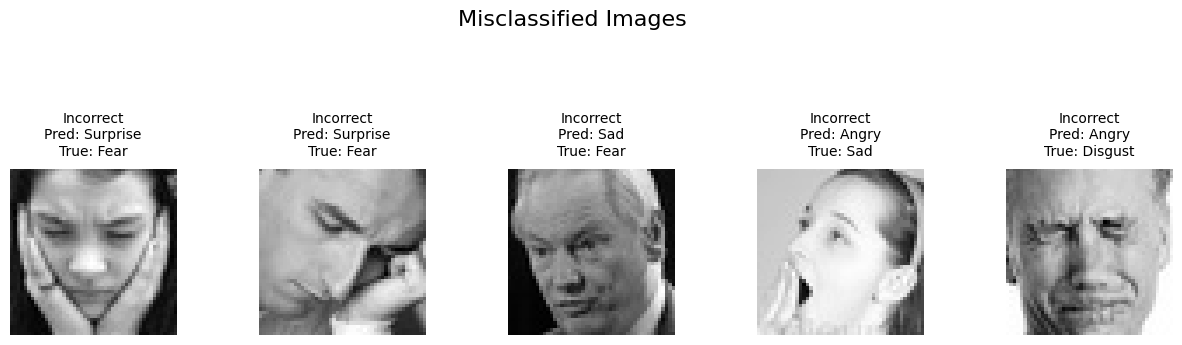

In [79]:
def show_random_predictions(test_data, emotion_mapping, num_images=5):
    
    batch = next(test_data)
    images, labels = batch[0], batch[1]

    
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(labels, axis=1)

    
    correct_indices = [i for i in range(len(predicted_labels)) if predicted_labels[i] == true_labels[i]]
    incorrect_indices = [i for i in range(len(predicted_labels)) if predicted_labels[i] != true_labels[i]]

    
    plt.figure(figsize=(15, 5))
    for i in range(min(num_images, len(correct_indices))):
        index = correct_indices[i]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[index], cmap='gray')
        plt.title(
            f"Correct\nPred: {emotion_mapping[predicted_labels[index]]}\nTrue: {emotion_mapping[true_labels[index]]}",
            pad=10, fontsize=10)
        plt.axis('off')
    plt.suptitle("Correctly Classified Images", fontsize=16)
    plt.subplots_adjust(wspace=0.5)
    plt.show()

    
    plt.figure(figsize=(15, 5))
    for i in range(min(num_images, len(incorrect_indices))):
        index = incorrect_indices[i]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[index], cmap='gray')
        plt.title(
            f"Incorrect\nPred: {emotion_mapping[predicted_labels[index]]}\nTrue: {emotion_mapping[true_labels[index]]}",
            pad=10, fontsize=10)
        plt.axis('off')
    plt.suptitle("Misclassified Images", fontsize=16)
    plt.subplots_adjust(wspace=0.5)
    plt.show()



emotion_mapping = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}
show_random_predictions(test_data, emotion_mapping)


In [43]:
model.save('emotion_recognition_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [ ]:

emotion_mapping = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}


Real-Time Emotion Detection
This function uses a webcam to detect faces and predict emotions in real-time.
Starts the webcam.
Used for detecting faces in the image.
Displays the real-time webcam feed with detected emotions.

Press 'q' to quit.


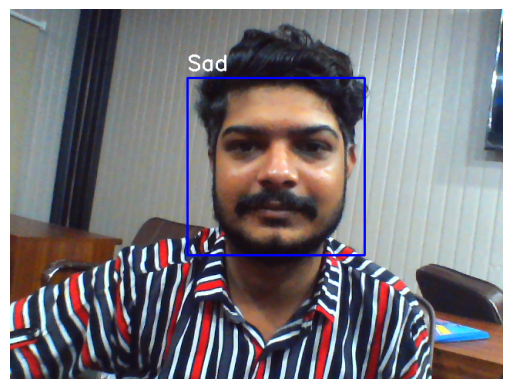

KeyboardInterrupt: 

In [91]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def real_time_emotion_detection(model, emotion_map):
    
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Camera not accessible.")
        return

    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

    print("Press 'q' to quit.")

    
    fig, ax = plt.subplots()

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to capture frame. Exiting...")
            break

       
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

        for (x, y, w, h) in faces:
            
            face = gray[y:y+h, x:x+w]  
            face = cv2.resize(face, (48, 48))  
            face = face.reshape(1, 48, 48, 1) / 255.0  

            
            prediction = model.predict(face, verbose=0)
            emotion_label = emotion_map[np.argmax(prediction)]  

            
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)  
            cv2.putText(frame, emotion_label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)  

        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        
        ax.clear()  
        ax.imshow(frame_rgb)  
        ax.axis('off')  

        
        plt.pause(0.001)

        

    
    cap.release()
    plt.close(fig)


emotion_mapping = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
real_time_emotion_detection(model, emotion_mapping)
